# Capstone Project - GNN for PPI Tissue Prediction

I am trying to replicate the OhmNet paper but using a Graph Attention Network (GAT) instead of just regular Node2Vec or whatever. It's been really hard to figure out how to handle all these different tissues.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch_geometric
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATConv
from torch_geometric.nn.conv import GATv2Conv
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader, LinkNeighborLoader
from torch_geometric.nn import Node2Vec
from torch_geometric.nn.inits import glorot
import pandas as pd
import numpy as np
import networkx as nx
import os
from pathlib import Path
import matplotlib.pyplot as plt
import gensim
from gensim.models.poincare import PoincareModel
import sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import gc
import pronto
from pronto import Ontology
from sklearn.model_selection import train_test_split
import random
import sys

# Checking if the GPU is active
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {device}")

if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Capability: {torch.cuda.get_device_capability(0)}")
    print(f"Total Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Current Memory Status
    allocated = torch.cuda.memory_allocated(0) / 1e9
    reserved = torch.cuda.memory_reserved(0) / 1e9
    print(f"Memory Allocated: {allocated:.2f} GB")
    print(f"Memory Reserved: {reserved:.2f} GB")
    
    # Multi-processor count (useful for understanding parallel processing power)
    print(f"Multi-processor count: {torch.cuda.get_device_properties(0).multi_processor_count}")

print(f"\nPyTorch version: {torch.__version__}")
print(f"PyTorch Geometric version: {torch_geometric.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"NetworkX version: {nx.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Pronto version: {pronto.__version__}")

# Data files location
data_dir = Path('./data')

Device used: cuda
GPU Name: NVIDIA GeForce RTX 3090 Ti
CUDA Capability: (8, 6)
Total Memory: 25.76 GB
Memory Allocated: 0.00 GB
Memory Reserved: 0.00 GB
Multi-processor count: 84

PyTorch version: 2.5.1+cu121
PyTorch Geometric version: 2.7.0
Pandas version: 3.0.0
NumPy version: 2.4.2
NetworkX version: 3.6.1
Gensim version: 4.4.0
Scikit-learn version: 1.8.0
Pronto version: 2.7.3


### Setting seed for reproducibility

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    """Ensures reproducibility when DataLoader num_workers > 0."""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

set_seed(42)

### EDA - Initial File Investigation

In [3]:
print("Looking at the data files...")
files = os.listdir(data_dir)
for f in files:
    size = os.path.getsize(data_dir / f) / (1024*1024)
    print(f"- {f} ({size:.2f} MB)")

# Visualized the data using basic txt file explorers (showing the files below for reference) and saw a couple of things of interest:
    # - BrendaTissue.obo: This is like a dictionary. I'll read it to map names like 'brain' to IDs like 'BTO:0000142'.
    # - tissue.hierarchy: This has parent-child pairs. I'll build a graph with it for Node2Vec and the custom loss.
    # - PPT-Ohmnet_tissues-combined.edgelist: The main data! 3.6M lines of PPIs. I have to group them by pair then collapse them into a pair-tissues multi-hot vectors

Looking at the data files...
- BrendaTissue.obo (1.74 MB)
- PPT-Ohmnet_tissues-combined.edgelist (78.07 MB)
- tissue.edges (0.01 MB)
- tissue.hierarchy (0.01 MB)


*BTO file*

In [4]:
onto = Ontology(str(data_dir / 'BrendaTissue.obo'))

#Print target tissue ontology
target_ids = ["BTO:0001388", "BTO:0000203", "BTO:0001387", "BTO:0000753"]
for tid in target_ids:
    if tid in onto:
        t = onto[tid]
        print(f"{t.id} -> {t.name}")
    else:
        print(f"{tid} not found in ontology")

print("\n")
with open(data_dir / 'BrendaTissue.obo', 'r', encoding='utf-8') as f:
    for i in range(20):
        print(f.readline().strip())

BTO:0001388 -> trachea
BTO:0000203 -> respiratory system
BTO:0001387 -> tonsil
BTO:0000753 -> lymphoid tissue


format-version: 1.2
date: 03:05:2016 09:39
saved-by: Marion, contact@brenda-enzymes.org
auto-generated-by: OBO-Edit 2.3.1
synonymtypedef: GE "LANGUAGE GERMAN"
synonymtypedef: SCI "SCIENTIFIC NAME"
default-namespace: BrendaTissueOBO
remark: www.brenda-enzymes.org

[Term]
id: BTO:0000000
name: tissues, cell types and enzyme sources
def: "A structured controlled vocabulary for the source of an enzyme. It comprises terms of tissues, cell lines, cell types and cell cultures from uni- and multicellular organisms." [curators:mgr]

[Term]
id: BTO:0000001
name: culture condition:-induced cell
is_a: BTO:0000216 ! culture condition

[Term]


*PPI Ohmnet file*

In [5]:
pd.read_csv(data_dir / 'PPT-Ohmnet_tissues-combined.edgelist', sep = '\t')

,# protein1,protein2,tissue
0,4790,79155,urinary_bladder
1,26039,6597,urinary_bladder
2,57154,3309,urinary_bladder
3,6631,9775,urinary_bladder
4,1855,8312,urinary_bladder
...,...,...,...
3666558,6045,1153,spermatocyte
3666559,10616,1387,spermatocyte
3666560,2033,7026,spermatocyte
3666561,324,1457,spermatocyte


*tissue.hierarchy*

In [6]:
pd.read_csv(data_dir / 'tissue.hierarchy', sep='\t', header=None)

,0,1
0,BTO:0001388,BTO:0000203_NODE
1,BTO:0001387,BTO:0000753_NODE
2,BTO:0003099_NODE,BTO:0000083_NODE
3,BTO:0003092_NODE,BTO:0003091_NODE
4,BTO:0003091_NODE,Root_NODE
...,...,...
213,BTO:0002295,BTO:0001515_NODE
214,BTO:0000562,BTO:0000088_NODE
215,BTO:0000620,BTO:0000651_NODE
216,BTO:0000199,BTO:0001369_NODE


### Building the tissue graph from tissue.hierarchy
I have to load the tissue hierarchy. I struggled a lot here because I didn't realize it was a directed graph and had issues with indexing.

In [7]:
# Load the tissue.hierarchy and build directed graph using networkx
tissue_hierarchy_path = data_dir / 'tissue.hierarchy'
G_tissue = nx.read_edgelist(str(tissue_hierarchy_path), create_using=nx.DiGraph())

print(f"The tissue graph has {G_tissue.number_of_nodes()} nodes.")

# Sort list and created indices these because we want the indices to be consistent
tissue_nodes = sorted(list(G_tissue.nodes()))
tissue_to_idx = {node: i for i, node in enumerate(tissue_nodes)}

# Making the edge index for the tissue hierarchy
edges_tissue = []
for u, v in G_tissue.edges():
    edges_tissue.append([tissue_to_idx[u], tissue_to_idx[v]])

# This part was tricky had to read the documentation for shape. I had to transpose it or it throws an error.
edges_index_tissue = torch.tensor(edges_tissue, dtype=torch.long).t().contiguous()
hierarchical_pairs = edges_index_tissue.t()

print(f"Tissue edge index shape processed: {edges_index_tissue.shape} ") # As per documentation shape has to be ([2, num_edges])

The tissue graph has 219 nodes.
Tissue edge index shape processed: torch.Size([2, 218]) 


### Mapping Tissues to BTO IDs
I found out that the PPI file uses names like 'brain' but my hierarchy uses BTO IDs like 'BTO:0000142'. I had to load this BrendaTissue.obo file and match them up manually. I even had to make a 'manual rescue' for tissues with different naming schemes (e.g. b_lymphocyte in PPI is not b lymphocyte but b-lymphocyte in the BTO).

In [8]:
print("Building mapping from BrendaTissue.obo...")
obo_path = data_dir / 'BrendaTissue.obo'
name_to_bto = {}
with open(obo_path, 'r', encoding='utf-8') as f:
    curr_id = None
    for line in f:
        line = line.strip()
        if line.startswith('id: '):
            curr_id = line[4:]
        elif line.startswith('name: ') and curr_id:
            name_to_bto[line[6:].lower()] = curr_id

# I found this manual rescue because some tissues are just named inconsistently in the data
manual_rescue = {
    'culture condition cd8 cell': 'BTO:0004410',
    'b lymphocyte': 'BTO:0000776',
    'b lymphocytes': 'BTO:0000776', 
    't lymphocyte': 'BTO:0000782', 
    't lymphocytes': 'BTO:0000782'  
}

def get_tissue_idx(t_name):
    # The PPI file uses underscores but names in OBO usually have spaces
    normalized = str(t_name).lower().replace('_', ' ')
    if normalized in manual_rescue:
        bto_id = manual_rescue[normalized]
    else:
        bto_id = name_to_bto.get(normalized)
        
    if not bto_id:
        return None
    
    if bto_id in tissue_to_idx:
        return tissue_to_idx[bto_id]
    if bto_id + '_NODE' in tissue_to_idx:
        return tissue_to_idx[bto_id + '_NODE']
    return None

print(f"Loaded {len(name_to_bto)} names and manual rescues for mapping.")

Building mapping from BrendaTissue.obo...
Loaded 5903 names and manual rescues for mapping.


### Preprocessing PPI Data
Now I have to load the actual protein-protein interactions. I have to map the tissues properly for the multi-hot labeling to work.

In [9]:
# Load the PPI file
ppi_file = data_dir / 'PPT-Ohmnet_tissues-combined.edgelist'
df = pd.read_csv(ppi_file, sep='\t')
df.columns = ['protein_a', 'protein_b', 'tissue']
original_count = len(df)


print("Applying tissue mapping...")
df['t_idx'] = df['tissue'].apply(get_tissue_idx)
df = df.dropna(subset=['t_idx'])
mapped_count = len(df)

print(f"Mapped {mapped_count}/{original_count} PPI records successfully!")

# Getting all unique proteins.
all_proteins = sorted(pd.concat([df['protein_a'], df['protein_b']]).unique())
protein_to_idx = {prot: i for i, prot in enumerate(all_proteins)}
num_unique_proteins = len(all_proteins)

print(f"Found {num_unique_proteins} unique proteins.")

Applying tissue mapping...
Mapped 3666563/3666563 PPI records successfully!
Found 4510 unique proteins.


### Handling Labels (Tissues)
Each interaction happens in certain tissues. I need to make a vector where it's 1 if the interaction happens there. I have to group by (protein_a, protein_b) and combine the tissues.

In [10]:
# Grouping by interaction to see which tissues they are in
interaction_groups = df.groupby(['protein_a', 'protein_b'])

# 219
num_tissues = len(tissue_nodes)
# 70338
num_interactions = len(interaction_groups)

# (70338, 219)
labels_matrix = np.zeros((num_interactions, num_tissues))
edge_list_all = []


for i, ((p1, p2), group) in enumerate(interaction_groups):
    u = protein_to_idx[p1]
    v = protein_to_idx[p2]
    edge_list_all.append([u, v])
    
    # Collect all tissues for this pair
    tissues_present_indices = group['t_idx'].unique()
    for tidx in tissues_present_indices:
        labels_matrix[i, int(tidx)] = 1.0

# ([2, 70338]) 
edge_label_index_all = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
# ([70338,219])
edge_label_all = torch.tensor(labels_matrix, dtype=torch.float)

print("Grouped unique interactions:", num_interactions)
print("Final Label Matrix Shape:", edge_label_all.shape)

# I need the 107 leaf nodes for the final score, needed help
leaf_node_indices = [i for i, node in enumerate(tissue_nodes) if G_tissue.in_degree(node) == 0 and node != 'Root_NODE']
print(f"Found {len(leaf_node_indices)} leaf tissues.")

Grouped unique interactions: 70338
Final Label Matrix Shape: torch.Size([70338, 219])
Found 107 leaf tissues.


In [11]:
# LABEL PROPAGATION: Ensuring hierarchical consistency in ground truth (True Path Rule)
# If a child tissue is active (1), all its ancestors must also be active (1).
# This is the data cleanup that was assisted by AI, there were interactions in child tissues that weren't noted in parent tissue in the OhmNet dataset
# which is biologically/hierarchically impossible. This algorithm corrects that.

print("Propagating labels through hierarchy...")
new_labels_matrix = labels_matrix.copy()
# Precalculate ancestor indices for each tissue index
ancestor_map = {}
for idx, node in enumerate(tissue_nodes):
    # In G_tissue, edges are Child -> Parent
    # nx.descendants follows outgoing edges, which in this DAG means parents/grandparents (i.e. ancestors)
    ancestors = nx.descendants(G_tissue, node)
    ancestor_map[idx] = [tissue_to_idx[anc] for anc in ancestors if anc in tissue_to_idx]
# Apply propagation
for i in range(num_interactions):
    active_indices = np.where(labels_matrix[i] == 1)[0]
    for tidx in active_indices:
        for anc_idx in ancestor_map[tidx]:
            new_labels_matrix[i, anc_idx] = 1.0
# Update the tensors used by the model
edge_label_all = torch.tensor(new_labels_matrix, dtype=torch.float)
# Calculate Tissue Coverage (how many of the 219 tissues have >= 1 interaction)
tissues_with_labels_orig = (labels_matrix.sum(axis=0) > 0).sum()
tissues_with_labels_prop = (new_labels_matrix.sum(axis=0) > 0).sum()
# Verification
print(f"--- Global Density (All 219 Nodes) ---")
print(f"Original label density: {labels_matrix.mean():.4%}")
print(f"Propagated label density: {new_labels_matrix.mean():.4%}")
print(f"\n--- Tissue Coverage ---")
print(f"Tissues represented in raw PPI: {tissues_with_labels_orig} / 219 ({tissues_with_labels_orig/219:.1%})")
print(f"Tissues active after Propagation: {tissues_with_labels_prop} / 219 ({tissues_with_labels_prop/219:.1%})")
# Calculate leaf node density specifically
leaf_density_prop = new_labels_matrix[:, leaf_node_indices].mean()
print(f"\n--- Specific Metrics ---")
print(f"Propagated leaf node density: {leaf_density_prop:.4%}")
print("\nLabel propagation complete. Re-splitting data is required to update loaders.")

Propagating labels through hierarchy...
--- Global Density (All 219 Nodes) ---
Original label density: 23.8026%
Propagated label density: 38.3389%

--- Tissue Coverage ---
Tissues represented in raw PPI: 144 / 219 (65.8%)
Tissues active after Propagation: 219 / 219 (100.0%)

--- Specific Metrics ---
Propagated leaf node density: 30.5682%

Label propagation complete. Re-splitting data is required to update loaders.


### Identifying novel tissues after propagation

In [12]:
# CODE TO IDENTIFY GAINED TISSUES AFTER PROPAGATION
# This helps us see which "Parent" or "Ancestor" nodes were rescued 

# Create an inverse mapping to find names for BTO IDs
bto_to_name = {bto: name for name, bto in name_to_bto.items()}

# Compare representation before and after propagation
orig_counts = labels_matrix.sum(axis=0)
prop_counts = new_labels_matrix.sum(axis=0)

# Find indices where original count was 0 but propagated count is > 0
gained_indices = np.where((orig_counts == 0) & (prop_counts > 0))[0]
gained_data = []

for i in gained_indices:
    bto_id = tissue_nodes[i]
    # Handle the '_NODE' suffix used for structural hierarchy nodes
    lookup_id = bto_id.split('_')[0]
    name = bto_to_name.get(lookup_id, "Hierarchy Node")
    gained_data.append((bto_id, name))

print(f"Number of tissues/nodes that gained labels: {len(gained_data)}")
print("\n--- Tissues Represented via Propagation (Ancestors) ---")
# Sorting by BTO ID for clarity
for bto_id, name in sorted(gained_data):
    print(f"- {bto_id}: {name}")

# In the hierarchy podocyte is a child (and leaf) of glomerular epithelium

Number of tissues/nodes that gained labels: 75

--- Tissues Represented via Propagation (Ancestors) ---
- BTO:0000000_NODE: tissues, cell types and enzyme sources
- BTO:0000058_NODE: alimentary canal
- BTO:0000081_NODE: reproductive system
- BTO:0000082_NODE: male reproductive system
- BTO:0000083_NODE: female reproductive system
- BTO:0000088_NODE: cardiovascular system
- BTO:0000123_NODE: bladder
- BTO:0000125_NODE: blast cell
- BTO:0000128_NODE: blastula
- BTO:0000136_NODE: bronchoalveolar system
- BTO:0000146_NODE: brain stem
- BTO:0000149_NODE: breast
- BTO:0000174_NODE: embryonic structure
- BTO:0000202_NODE: sense organ
- BTO:0000203_NODE: respiratory system
- BTO:0000214_NODE: cell culture
- BTO:0000216_NODE: culture condition
- BTO:0000231_NODE: cerebral hemisphere
- BTO:0000284_NODE: organism form
- BTO:0000333_NODE: renal corpuscle
- BTO:0000345_NODE: digestive gland
- BTO:0000389_NODE: mature ovarian follicle
- BTO:0000393_NODE: endothelium
- BTO:0000416_NODE: epithelium
- 

### EDA - Visualizing our Labels
Now that I have the labels grouped, I can finally see what the data distribution looks like.

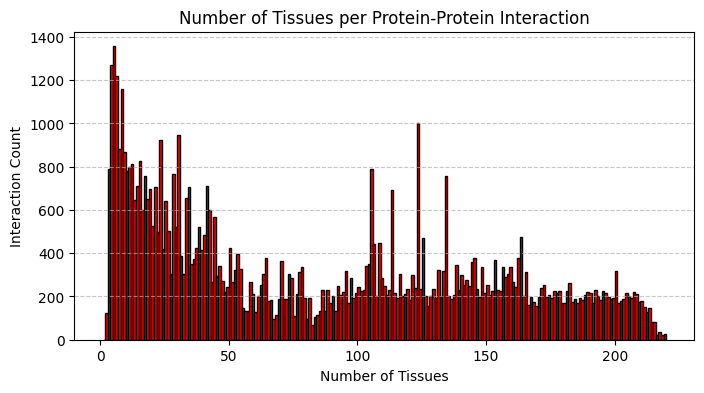

Average tissues per interaction: 83.96


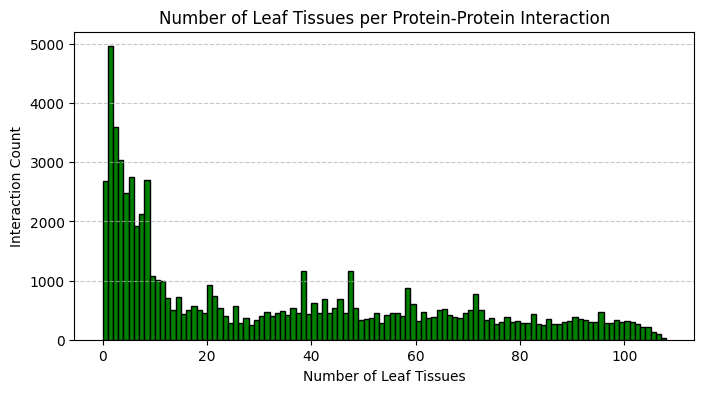

Max leaf tissues for a single interaction: 107.0
Average leaf tissues per interaction: 32.71


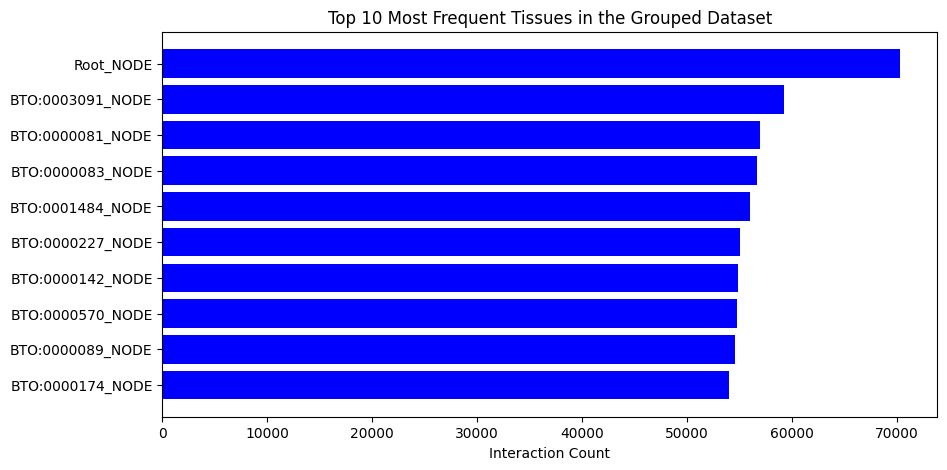

In [13]:
# EDA histogram: How many tissues per interaction?
plt.figure(figsize=(8, 4))
tissues_per_ppi = edge_label_all.sum(dim=1).numpy()
plt.hist(tissues_per_ppi, bins=range(1, int(tissues_per_ppi.max()) + 2), color='r', edgecolor='black')
plt.title("Number of Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average tissues per interaction: {tissues_per_ppi.mean():.2f}")

# EDA histogram: same but only for leaf tissues now (the ones that will be tested later)
# notice the change in scale of number of interactions, everything get skewed to the left which is a good sign for tissue specificity
# edge_label_all shape: [70338, 219]
# leaf_labels_only shape: [70338, 107]
leaf_labels_only = edge_label_all[:, leaf_node_indices]
# Now sum sideways across the 107 leaf tissues
leaf_tissues_per_ppi = leaf_labels_only.sum(dim=1).numpy()
plt.figure(figsize=(8, 4))
# Note: we use bins starting from 0 in case some PPIs have no leaf-level annotations
plt.hist(leaf_tissues_per_ppi, bins=range(0, int(leaf_tissues_per_ppi.max()) + 2), color='g', edgecolor='black')
plt.title("Number of Leaf Tissues per Protein-Protein Interaction")
plt.xlabel("Number of Leaf Tissues")
plt.ylabel("Interaction Count")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(f"Max leaf tissues for a single interaction: {leaf_tissues_per_ppi.max()}")
print(f"Average leaf tissues per interaction: {leaf_tissues_per_ppi.mean():.2f}")

# EDA barh: Top 10 Most Common Tissues?
plt.figure(figsize=(10, 5))
tissue_counts = edge_label_all.sum(dim=0).numpy()
top_indices = np.argsort(tissue_counts)[-10:]
plt.barh([tissue_nodes[i] for i in top_indices], tissue_counts[top_indices], color='b')
plt.title("Top 10 Most Frequent Tissues in the Grouped Dataset")
plt.xlabel("Interaction Count")
plt.show()

### Splitting the data
I need to divide this into train, validation, and test. The expert said to do an 80/20 split then split the 80% again to get the 72/8/20 ratio.

In [14]:
# I experimented with train/val/test as 80/10/10 vs the current 72/8/20 and the results were comparable for the same hyperparameters.
# I was getting test AUROC of 0.97xx-0.98xx depending on the training run and early stopping triggered between 870-940 epochs (results before the refinement of hierarchical penalty)
indices = np.arange(num_interactions)
# First split: 20% for testing
train_val_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, shuffle=True)
# Second split: 10% of the remaining for validation (which is 8% of total)
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.1, random_state=42, shuffle=True)

print(f"Train size: {len(train_idx)}, Val size: {len(val_idx)}, Test size: {len(test_idx)}")

# This works directly on the Tensor
    # Transductive leakage fix: edge_index for the graph should only contain training edges
train_edge_index = edge_label_index_all[:, train_idx]
undirected_train_edge_index = to_undirected(train_edge_index)

# Build a set of training edges for fast lookup during evaluation
# This allows val/test loaders to filter out supervision edges that leak into message-passing
_train_edge_set = set()
for i in range(undirected_train_edge_index.size(1)):
    u, v = undirected_train_edge_index[0, i].item(), undirected_train_edge_index[1, i].item()
    _train_edge_set.add((u, v))

def _filter_eval_message_edges(batch, train_edge_set):
    """Remove supervision (target) edges from batch.edge_index during evaluation
    to prevent target edges from appearing in the message-passing graph."""
    target_edges = set()
    for i in range(batch.edge_label_index.size(1)):
        u, v = batch.edge_label_index[0, i].item(), batch.edge_label_index[1, i].item()
        target_edges.add((u, v))
        target_edges.add((v, u))  # both directions
    # Only remove edges that are targets AND not part of the training graph
    edges_to_remove = target_edges - train_edge_set
    if len(edges_to_remove) == 0:
        return batch
    keep_mask = torch.ones(batch.edge_index.size(1), dtype=torch.bool)
    for i in range(batch.edge_index.size(1)):
        e = (batch.edge_index[0, i].item(), batch.edge_index[1, i].item())
        if e in edges_to_remove:
            keep_mask[i] = False
    batch.edge_index = batch.edge_index[:, keep_mask]
    return batch

# Re-create the graph data
full_graph_data = Data(x=torch.arange(num_unique_proteins), edge_index=undirected_train_edge_index)

# Increased batch size this so it trains faster and we have room on GPU (only about 10GB used during training according to my monitoring).
# Also tried with batch size of 4k and it led to having only 12 updates per epoch which wasn't great for faster convergence
batch_size = 1024 

# Generator for reproducible DataLoader shuffling
g = torch.Generator()
g.manual_seed(42)

# As mentioned in the project proposal, using neighbor sampling
train_loader = LinkNeighborLoader(
    full_graph_data,
    # 2 hops: 15 random neighbors sampled for each protein in the pair then these random neighbors select another 10 random neighbors
    # In total, 2 + 2*15 + 2*15*10 proteins are sampled each step with a batch size of 1024, that's about 340k proteins/neighborhoods per batch
    # the alternative to neighbor_loader is the entire graph which I tried with a low batch size and it was using 54GB of VRAM so I went OOM
    num_neighbors=[15, 10], 
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, train_idx],
    edge_label=edge_label_all[train_idx],
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, val_idx],
    edge_label=edge_label_all[val_idx],
    shuffle=False
)

test_loader = LinkNeighborLoader(
    full_graph_data,
    num_neighbors=[15, 10],
    batch_size=batch_size,
    edge_label_index=edge_label_index_all[:, test_idx],
    edge_label=edge_label_all[test_idx],
    shuffle=False
)

Train size: 50643, Val size: 5627, Test size: 14068


### Data leakage check

In [15]:
# Check if there is any overlap between sets
train_set = set(train_idx)
val_set = set(val_idx)
test_set = set(test_idx)

assert train_set.isdisjoint(val_set), "Leakage: Overlap between Train and Val"
assert train_set.isdisjoint(test_set), "Leakage: Overlap between Train and Test"
assert val_set.isdisjoint(test_set), "Leakage: Overlap between Val and Test"
print("Sets are perfectly disjoint. No label leakage.")

Sets are perfectly disjoint. No label leakage.


### Tissue Embeddings (Node2Vec)
Using Node2Vec to get features for the tissues.

In [16]:
# embedding_dim at 256d is slightly better than at 64/128d perhaps because we are working with 219 nodes so 256 offers a bit more "mathematical space"
# but the difference seems marginal but is significant, losses went from about 0.76xx to 0.74xx so slightly better
tissue_n2v_model = Node2Vec(edges_index_tissue, embedding_dim=256, walk_length=20, 
                            context_size=10, walks_per_node=10, num_negative_samples=1, 
                            sparse=True).to(device)

# Xavier uniform init chosen after observing astronimical losses and slow convergence (l=4.7), Xavier used because it was used in the GAT paper but I didn't try other methods
# I am aware we are not training a GAT here but I still chose Xavier uniform init because it's the first that came to mind after reading the paper and the results were satisfactory
torch.nn.init.xavier_uniform_(tissue_n2v_model.embedding.weight)
#batch size initially set at 128 but with N = 219, there were 2 updates per epoch, to increase stochasticity, I opted for a batch size of 32 but the losses didn't really improve
n2v_loader = tissue_n2v_model.loader(batch_size=32, shuffle=True, num_workers=0) 
n2v_optimizer = torch.optim.SparseAdam(list(tissue_n2v_model.parameters()), lr=0.01)

tissue_n2v_model.train()
for epoch in range(1, 1001):
    total_loss = 0
    for pos_rw, neg_rw in n2v_loader:
        n2v_optimizer.zero_grad()
        loss = tissue_n2v_model.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        n2v_optimizer.step()
        total_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Node2Vec Epoch {epoch}, Loss: {total_loss/len(n2v_loader):.4f}")
# Calling model() executes the forward() method which returns the entire embedding matrix and detach() to prevent the GAT model from backpropagating back to N2V model weights
global_tissue_address = tissue_n2v_model().detach() 
print("Tissue embeddings ready.")
# The reason the loss is low and remains low is that it is a very easy problem to solve for a model -> a tree is a DAG and with 256d, it's easy for the model to place things where
# they need to be.
"""
# 10D Poincare Embeddings for Tissue Hierarchy
# Hyperbolic space (Poincare manifold) is mathematically superior for tree hierarchies like the BTO.
print("Generating 10D Poincare embeddings for tissue hierarchy...")

# Prepare edges for PoincareModel (Actual node names/IDs)
poincare_edges = []
for u_idx, v_idx in edges_tissue:
    poincare_edges.append((tissue_nodes[u_idx], tissue_nodes[v_idx]))

# Train Poincare Model
# size=10 as requested. 100 epochs is sufficient for structural convergence on this 219-node hierarchy.
poincare_model = PoincareModel(poincare_edges, size=10, negative=5)
poincare_model.train(epochs=100)

# Extract embeddings in the deterministic order defined by tissue_nodes
poincare_weights = [poincare_model.kv[node] for node in tissue_nodes]

# global_tissue_address will be used by the LateFusionGAT model
global_tissue_address = torch.tensor(np.array(poincare_weights), dtype=torch.float).to(device)
tissue_address_dim = global_tissue_address.shape[1]

print(f"Poincare embeddings ready. Shape: {global_tissue_address.shape}")
"""


Node2Vec Epoch 100, Loss: 0.7674
Node2Vec Epoch 200, Loss: 0.7507
Node2Vec Epoch 300, Loss: 0.7511
Node2Vec Epoch 400, Loss: 0.7462
Node2Vec Epoch 500, Loss: 0.7475
Node2Vec Epoch 600, Loss: 0.7474
Node2Vec Epoch 700, Loss: 0.7436
Node2Vec Epoch 800, Loss: 0.7473
Node2Vec Epoch 900, Loss: 0.7442
Node2Vec Epoch 1000, Loss: 0.7448
Tissue embeddings ready.


'\n# 10D Poincare Embeddings for Tissue Hierarchy\n# Hyperbolic space (Poincare manifold) is mathematically superior for tree hierarchies like the BTO.\nprint("Generating 10D Poincare embeddings for tissue hierarchy...")\n\n# Prepare edges for PoincareModel (Actual node names/IDs)\npoincare_edges = []\nfor u_idx, v_idx in edges_tissue:\n    poincare_edges.append((tissue_nodes[u_idx], tissue_nodes[v_idx]))\n\n# Train Poincare Model\n# size=10 as requested. 100 epochs is sufficient for structural convergence on this 219-node hierarchy.\npoincare_model = PoincareModel(poincare_edges, size=10, negative=5)\npoincare_model.train(epochs=100)\n\n# Extract embeddings in the deterministic order defined by tissue_nodes\npoincare_weights = [poincare_model.kv[node] for node in tissue_nodes]\n\n# global_tissue_address will be used by the LateFusionGAT model\nglobal_tissue_address = torch.tensor(np.array(poincare_weights), dtype=torch.float).to(device)\ntissue_address_dim = global_tissue_address.shap

### Visualizing the tissue hierarchy

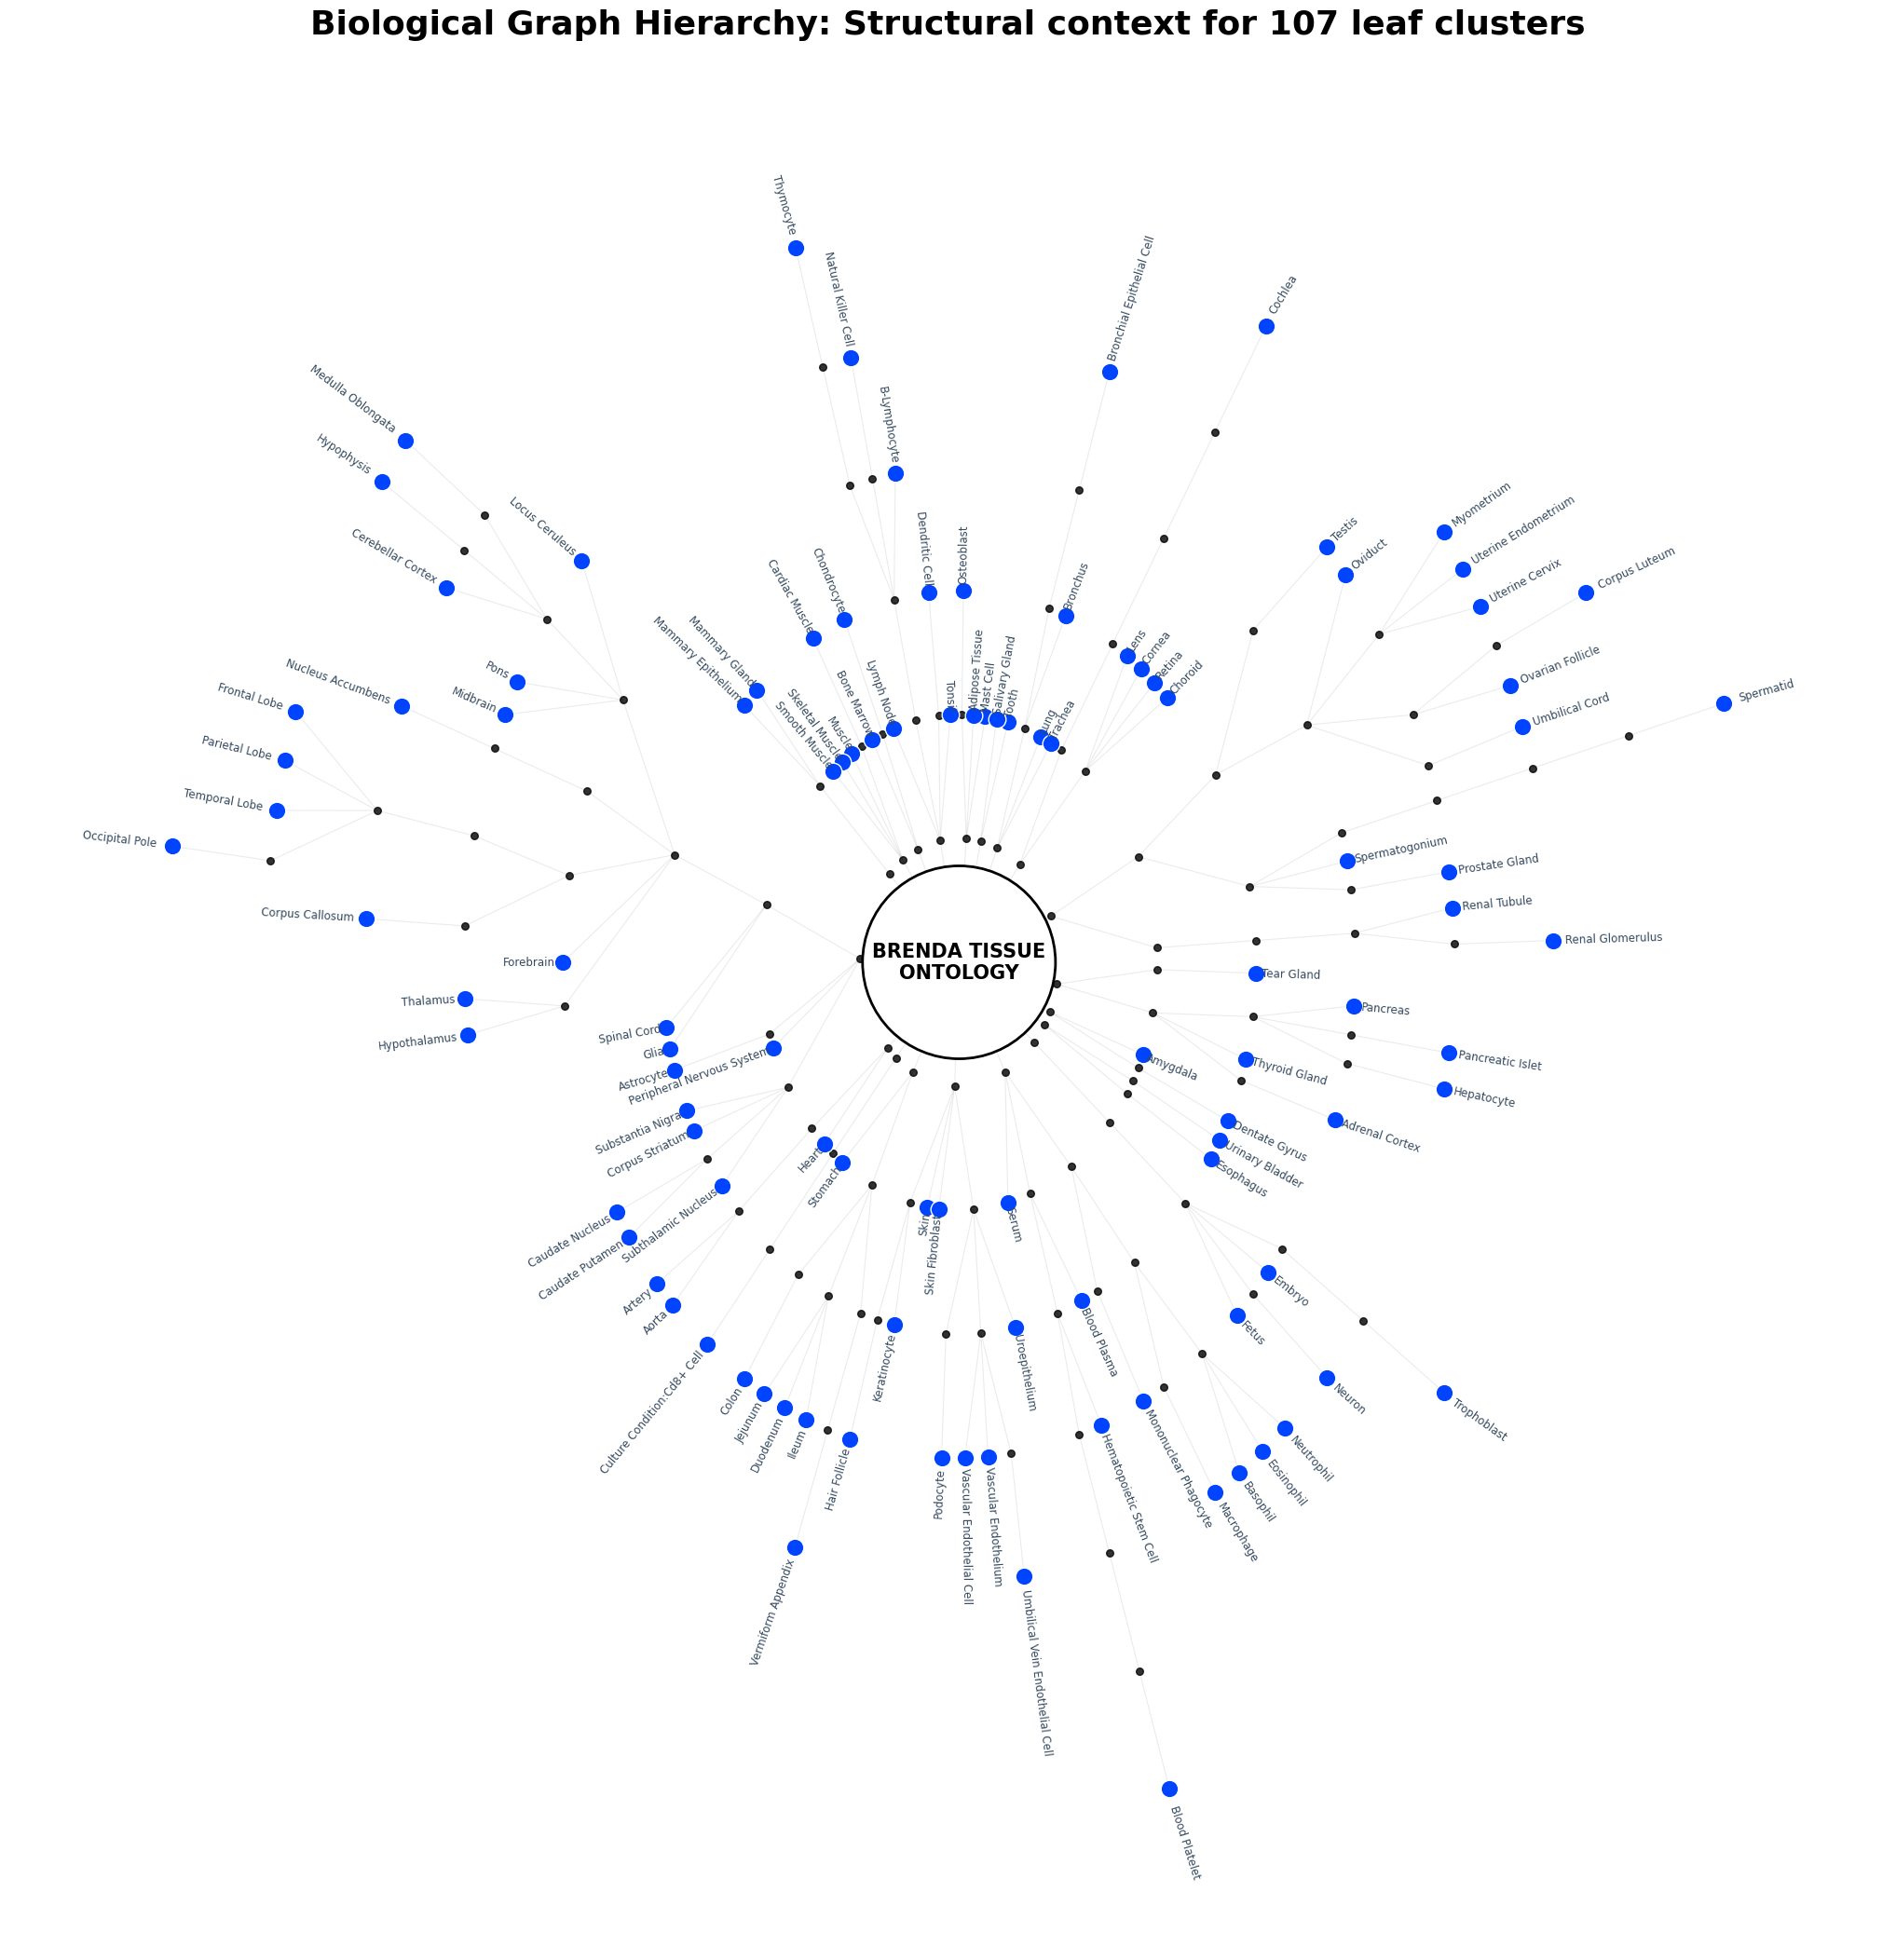

In [17]:
# VERY IMPORTANT! This code is not mine and therefore should not be considered in my grading. I just thought it was a good visual to include in the report.
# 1. Setup metadata
bto_to_name = {v: k.title() for k, v in name_to_bto.items()}
# Based on your previous code, in_degree == 0 are leaf nodes, so edges are bottom-up (Leaf -> Parent)
leaf_tissues = sorted([n for n in G_tissue.nodes() if G_tissue.in_degree(n) == 0])
internal_nodes = [n for n in G_tissue.nodes() if n not in leaf_tissues]
root_node = 'Root_NODE'
# 2. Robust Radial Layout Algorithm
def get_radial_pos(G, root, radius_step=1.2):
    # Initialize all nodes with (0,0) so we don't get KeyErrors
    pos = {node: (0, 0) for node in G.nodes()}
    
    # Helper to calculate subtree sizes for angular weighting
    # Since edges are Leaf -> Root, children of a node are its PREDECESSORS
    def get_subtree_leaves(node, visited):
        if node in visited: return 0
        visited.add(node)
        children = list(G.predecessors(node))
        if not children:
            return 1
        return sum(get_subtree_leaves(c, visited) for c in children)
    def assign_angles(node, start_angle, end_angle, depth, visited):
        if node in visited: return
        visited.add(node)
        
        children = list(G.predecessors(node))
        if not children:
            return
        
        r = depth * radius_step
        
        # Calculate weights for each sub-branch
        weights = []
        for c in children:
            weights.append(get_subtree_leaves(c, set()))
        
        total_weight = sum(weights)
        current_angle = start_angle
        
        for child, weight in zip(children, weights):
            sector_width = (end_angle - start_angle) * (weight / total_weight)
            angle = current_angle + sector_width / 2
            
            # Polar to Cartesian
            pos[child] = (r * np.cos(angle), r * np.sin(angle))
            
            # Recurse
            assign_angles(child, current_angle, current_angle + sector_width, depth + 1, visited)
            current_angle += sector_width
    # Run the recursive position assignment
    assign_angles(root, 0, 2 * np.pi, 1, set())
    return pos
# Generate the 360-degree layout
pos = get_radial_pos(G_tissue, root_node, radius_step=1.5)
# 3. Enhanced Plotting
fig, ax = plt.subplots(figsize=(26, 26))
ax.set_facecolor('white')
# 4. Draw Edges (Clean thin lines)
nx.draw_networkx_edges(G_tissue, pos, alpha=0.1, edge_color='#2c3e50', width=0.8, arrows=False)
# 5. Draw Internal Nodes (Small black pivot points)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=internal_nodes, 
                       node_size=30, node_color='black', alpha=0.8)
# 6. Draw Leaf Tissues (Solid Pro Blue)
nx.draw_networkx_nodes(G_tissue, pos, nodelist=leaf_tissues, 
                       node_size=180, node_color='#0044ff', edgecolors='white', linewidths=1.0)
# 7. Adaptive Smart Labeling
for node in G_tissue.nodes():
    x, y = pos[node]
    # Skip labeling the root center to keep it clean
    if node == root_node: continue
    
    clean_id = node.replace('_NODE', '')
    name = bto_to_name.get(clean_id, clean_id)
    
    # Calculate angle for text rotation/alignment
    angle = np.arctan2(y, x)
    angle_deg = np.degrees(angle)
    
    # Leaves: Label them at the ends of branches
    if node in leaf_tissues:
        # Flip text if it's on the left side of the circle so it's always readable
        ha = 'left' if abs(angle_deg) < 90 else 'right'
        rotation = angle_deg if abs(angle_deg) < 90 else angle_deg + 180
        
        plt.text(x * 1.02, y * 1.02, name, 
                 fontsize=8.5, ha=ha, va='center', 
                 rotation=rotation, rotation_mode='anchor',
                 color='#34495e')
    # Major Hubs: Label significant branching points horizontally for emphasis
    elif G_tissue.out_degree(node) > 0 and G_tissue.in_degree(node) > 6:
        plt.text(x, y + 0.15, name.upper(), 
                 fontsize=12, fontweight='black', 
                 ha='center', va='bottom', color='black',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1))
# 8. Centerpiece
plt.text(0, 0, "BRENDA TISSUE\nONTOLOGY", fontsize=15, fontweight='black', 
         ha='center', va='center', color='black',
         bbox=dict(boxstyle='circle,pad=0.5', facecolor='white', edgecolor='black', lw=2))
plt.axis('off')
plt.title("Biological Graph Hierarchy: Structural context for 107 leaf clusters", 
          fontsize=26, fontweight='bold', pad=40)
plt.show()

### Defining the Model
Late Fusion GAT model.

In [18]:
# Needed help to define this, some parts were easy like self.gat1, self.gat2, self.gat3 and self.mlp but defining the forward method was harder because of skip connections
class LateFusionGAT(nn.Module):
    def __init__(self, num_proteins, protein_embedding_dim, num_heads, gat_hidden_channels, 
                 gat_output_channels, tissue_address_dim, mlp_hidden_channels, 
                 num_tissues, global_tissue_address_tensor, dropout_rate=0.3):
        super().__init__()
        self.num_tissues = num_tissues
        self.global_tissue_address = nn.Parameter(global_tissue_address_tensor, requires_grad=False)
        self.protein_embedding = nn.Embedding(num_proteins, protein_embedding_dim)
        
        self.gat1 = GATv2Conv(protein_embedding_dim, gat_hidden_channels, heads=num_heads, dropout=dropout_rate)
        self.skip1 = nn.Linear(protein_embedding_dim, gat_hidden_channels * num_heads)
        
        self.gat2 = GATv2Conv(gat_hidden_channels * num_heads, gat_hidden_channels, heads=num_heads, concat=True, dropout=dropout_rate)
        self.skip2 = nn.Linear(gat_hidden_channels * num_heads, gat_hidden_channels * num_heads)
        
        self.gat3 = GATv2Conv(gat_hidden_channels * num_heads, gat_output_channels, heads=1, concat=False, dropout=dropout_rate)
        
        # MLP Head with concatenated protein dims and tissue addres dims
        combined_dim = gat_output_channels * 2 + tissue_address_dim
        self.mlp = nn.Sequential(
            nn.Linear(combined_dim, mlp_hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(mlp_hidden_channels, 1)
        )
        self.reset_parameters()
    def reset_parameters(self):
        glorot(self.protein_embedding.weight)
        self.gat1.reset_parameters()
        self.gat2.reset_parameters()
        self.gat3.reset_parameters()
        glorot(self.skip1.weight)
        glorot(self.skip2.weight)
        # MLP weights
        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                glorot(layer.weight)
    def forward(self, batch, return_attention_weights=False):
        # batch is already on the correct device via batch.to(device) in the training loop
        edge_index = batch.edge_index
        x_in = self.protein_embedding(batch.x)
        
        # GAT 1 + Skip (help for skip)
        x = self.gat1(x_in, edge_index)
        x = F.elu(x + self.skip1(x_in))
        
        # GAT 2 + Skip (help for skip)
        x_prev = x
        x = self.gat2(x, edge_index)
        x = F.elu(x + self.skip2(x_prev))
        
        # GAT 3 (Final features) - optionally return attention weights
        if return_attention_weights:
            x, (att_edge_index, att_weights) = self.gat3(x, edge_index, return_attention_weights=True)
        else:
            x = self.gat3(x, edge_index)
        
        # The rest of the code is the Late Fusion Logic
        u_idx, v_idx = batch.edge_label_index[0], batch.edge_label_index[1]
        u_feat, v_feat = x[u_idx], x[v_idx] 
        
        batch_size = u_feat.size(0)
        
        # Complex but necessary expansion - I needed help to visualize the shapes and adjust dimensions
        u_feat_exp = u_feat.unsqueeze(1).expand(-1, self.num_tissues, -1)
        v_feat_exp = v_feat.unsqueeze(1).expand(-1, self.num_tissues, -1)
        tissue_feat = self.global_tissue_address.unsqueeze(0).expand(batch_size, -1, -1)
        
        # Concatenation of tissue embeddings to protein embeddings to pass to MLP layer
        combined = torch.cat([u_feat_exp, v_feat_exp, tissue_feat], dim=-1)
        
        # Last dimension operation: Linear handles 3D tensors automatically
        out = self.mlp(combined).squeeze(-1)
        logits = torch.sigmoid(out)
        
        if return_attention_weights:
            return logits, (att_edge_index, att_weights)
        return logits

### Custom Loss Function
Adding a penalty for hierarchy violations.

In [ ]:
# HIERARCHICAL TOOLS: Loss Function and Violation Checking
# I designed the first version of custom_loss but had assistance to build the final version along with the check_hierarchical_violations()
def custom_loss(predictions, targets, hierarchy_edges, lambda_penalty=0.1, margin=0.01):

    bce = F.binary_cross_entropy(predictions, targets)
    
    child_idx, parent_idx = hierarchy_edges[:, 0], hierarchy_edges[:, 1]
    
    child_probs = predictions[:, child_idx]
    parent_probs = predictions[:, parent_idx]
    
    # We penalize if child_prob + margin > parent_prob
    # This forces the parent to be slightly higher than the child
    diff = (child_probs - parent_probs) + margin
    penalty = torch.mean(torch.clamp(diff, min=0)**2)
    
    return bce + lambda_penalty * penalty, bce, penalty

def check_hierarchical_violations(model, data_loader, hierarchical_pairs, device):
    model.eval()
    total_violations = 0
    total_checks = 0
    
    child_indices = hierarchical_pairs[:, 0]
    parent_indices = hierarchical_pairs[:, 1]
    
    with torch.no_grad():
        for batch in data_loader:
            batch = batch.to(device)
            preds = model(batch) 
            
            child_probs = preds[:, child_indices]
            parent_probs = preds[:, parent_indices]
            
            # Count cases where child exceeds parent (consistent with custom_loss)
            violations = (child_probs > parent_probs).sum().item()
            total_violations += violations
            total_checks += (preds.size(0) * hierarchical_pairs.size(0))
            
    if total_checks == 0: return 0.0, 0, 0
    return total_violations / total_checks, total_violations, total_checks

### THE TRAINING LOOP
Model hyperparameters with wandb and model instantiation separated from the training loop to load the model later.

In [20]:
import wandb

from dotenv import load_dotenv

load_dotenv()

print(f"WandB version: {wandb.__version__}")

wandb.login()

wandb.init(
    entity="steven-rav-concordia-university",
    project="Ohmnet GAT extension",
    settings=wandb.Settings(init_timeout=120, symlink=False),
    config={
        "num_proteins": num_unique_proteins,
        "num_tissues": num_tissues,
        "protein_embedding_dim": 256,
        "num_heads": 8,
        "gat_hidden_channels": 256,
        "gat_output_channels": 256,
        "mlp_hidden_channels": 1024,
        "dropout_rate": 0.3,
        "tissue_address_dim": global_tissue_address.shape[1],
        "learning_rate": 0.0005,
        "num_epochs": 1000,
        "patience": 50,
        "batch_size": 1024,
        "initial_lambda": 200,
        "violation_threshold": 0.01,
        "lambda_multiplier": 1.1,
        "max_lambda": 300.0,
        "seed": 42
    }
)
config = wandb.config
# Model initialization
model = LateFusionGAT(
    num_proteins=config.num_proteins, 
    protein_embedding_dim=config.protein_embedding_dim,
    num_heads=config.num_heads, 
    gat_hidden_channels=config.gat_hidden_channels,
    gat_output_channels=config.gat_output_channels, 
    tissue_address_dim=config.tissue_address_dim,
    mlp_hidden_channels=config.mlp_hidden_channels, 
    num_tissues=config.num_tissues,
    global_tissue_address_tensor=global_tissue_address, 
    dropout_rate=config.dropout_rate
).to(device)

WandB version: 0.18.7


ERROR:wandb.jupyter:Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: steven-rav (steven-rav-concordia-university). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


Training with early stopping.

In [21]:
# ADAPTIVE TARGET TRAINING LOOP (Tracked with Weights & Biases)
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
num_epochs = config.num_epochs
patience = config.patience
best_val_loss = float('inf')
epochs_no_improve = 0
current_lambda = config.initial_lambda

history = {
    'train': [], 'val': [], 
    'train_bce': [], 'train_penalty': [],
    'val_bce': [], 'val_penalty': [],
    'val_violation_rate': [],
    'lambda_history': []
}

if 'hierarchical_pairs' not in globals():
    hierarchical_pairs = edges_index_tissue.t()
hier_pairs_dev = hierarchical_pairs.to(device)

print(f"Starting Adaptive Training (Target: <{config.violation_threshold:.0%}, Initial Lambda: {current_lambda})...")

for epoch in range(num_epochs):
    model.train()
    total_train_loss, total_train_bce, total_train_pen = 0, 0, 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        preds = model(batch)
        
        # Binary Cross Entropy + Adaptive Hierarchical Penalty
        loss, bce, penalty = custom_loss(preds, batch.edge_label, hier_pairs_dev, 
                                         lambda_penalty=current_lambda)
        
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        total_train_bce += bce.item()
        total_train_pen += penalty.item()
        
    # Validation step - filter out supervision edges from message-passing to prevent leakage
    model.eval()
    total_val_loss, total_val_bce, total_val_pen = 0, 0, 0
    with torch.no_grad():
        for batch in val_loader:
            batch = _filter_eval_message_edges(batch, _train_edge_set)
            batch = batch.to(device)
            preds = model(batch)
            loss, bce, penalty = custom_loss(preds, batch.edge_label, hier_pairs_dev, lambda_penalty=current_lambda)
            total_val_loss += loss.item()
            total_val_bce += bce.item()
            total_val_pen += penalty.item()
    
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    
    # Check Violations and Update Lambda (Every 5 epochs)
    v_rate = None
    if (epoch + 1) % 5 == 0 or epoch == 0:
        v_rate, v_count, v_total = check_hierarchical_violations(model, train_loader, hier_pairs_dev, device)
        history['val_violation_rate'].append(v_rate)
        
        # TARGET-BASED ADAPTIVE SCHEDULING
        if v_rate > config.violation_threshold:
            current_lambda = min(current_lambda * config.lambda_multiplier, config.max_lambda)
            print(f"--- Violation Threshold Exceeded ({v_rate:.2%})! New Lambda: {current_lambda:.2f} ---")
        else:
            print(f"--- Hierarchy Stable ({v_rate:.2%}). Lambda Fixed. ---")
            
        print(f"Epoch {epoch+1:03d} | BCE: {total_train_bce/len(train_loader):.4f} | Pen: {total_train_pen/len(train_loader):.6f}")
        print(f"Losses | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f}")

    # Log metrics to W&B
    wandb_metrics = {
        "epoch": epoch + 1,
        "train/loss": avg_train_loss,
        "val/loss": avg_val_loss,
        "train/bce": total_train_bce / len(train_loader),
        "val/bce": total_val_bce / len(val_loader),
        "train/penalty": total_train_pen / len(train_loader),
        "val/penalty": total_val_pen / len(val_loader),
        "params/lambda": current_lambda,
        "params/patience_counter": epochs_no_improve
    }
    if v_rate is not None:
        wandb_metrics["val/hierarchy_violation_rate"] = v_rate
    
    wandb.log(wandb_metrics)

    # Early Stopping & Checkpointing
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
        wandb.save('best_model.pt') 
    else:
        epochs_no_improve += 1
    
    if epochs_no_improve >= patience:
        print(f"Early stopping at epoch {epoch+1}!")
        break

# Mark the run as finished
wandb.finish()

Starting Adaptive Training (Target: <1%, Initial Lambda: 200)...
--- Violation Threshold Exceeded (3.11%)! New Lambda: 220.00 ---
Epoch 001 | BCE: 0.6577 | Pen: 0.000169
Losses | Train: 0.6915 | Val: 0.6133
--- Hierarchy Stable (0.30%). Lambda Fixed. ---
Epoch 005 | BCE: 0.3553 | Pen: 0.000009
Losses | Train: 0.3574 | Val: 0.3302
--- Violation Threshold Exceeded (1.29%)! New Lambda: 242.00 ---
Epoch 010 | BCE: 0.2957 | Pen: 0.000009
Losses | Train: 0.2977 | Val: 0.2795
--- Violation Threshold Exceeded (1.17%)! New Lambda: 266.20 ---
Epoch 015 | BCE: 0.2736 | Pen: 0.000009
Losses | Train: 0.2757 | Val: 0.2599
--- Violation Threshold Exceeded (1.39%)! New Lambda: 292.82 ---
Epoch 020 | BCE: 0.2596 | Pen: 0.000010
Losses | Train: 0.2621 | Val: 0.2486
--- Violation Threshold Exceeded (1.58%)! New Lambda: 300.00 ---
Epoch 025 | BCE: 0.2453 | Pen: 0.000010
Losses | Train: 0.2482 | Val: 0.2331
--- Violation Threshold Exceeded (1.42%)! New Lambda: 300.00 ---
Epoch 030 | BCE: 0.2369 | Pen: 0.00

KeyboardInterrupt: 

### Extract attention coefficients

In [ ]:
# Extract the final attention coefficients from the last GAT layer after training
model.eval()
with torch.no_grad():
    all_att_edges = []
    all_att_weights = []
    for batch in test_loader:
        batch = batch.to(device)
        _, (att_edge_index, att_weights) = model(batch, return_attention_weights=True)
        all_att_edges.append(att_edge_index.cpu())
        all_att_weights.append(att_weights.cpu())
    
    attention_data = {
        "edge_indices": all_att_edges,
        "attention_weights": all_att_weights
    }
    torch.save(attention_data, "final_attention_coefficients.pt")
    if wandb.run is not None:
        wandb.save("final_attention_coefficients.pt")
    else:
        print("Wandb run finished, saved locally.")
    print(f"Saved attention coefficients from {len(all_att_edges)} batches.")

### Plotting loss curves

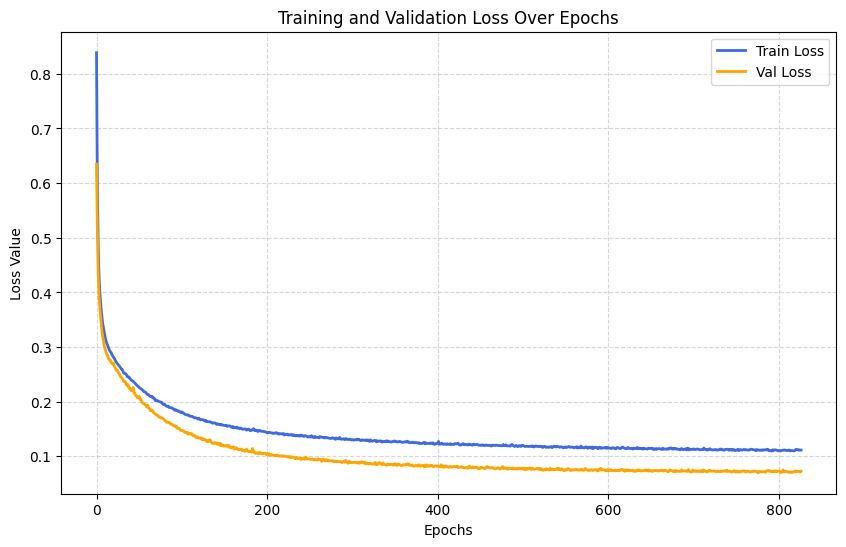

In [ ]:
# I wanted to see the learning curve of the model, val losses consistently under train losses because of dropout I believe, I've seen this training CNNs in the past
plt.figure(figsize=(10, 6))
plt.plot(history['train'], label='Train Loss', color='royalblue', linewidth=2)
plt.plot(history['val'], label='Val Loss', color='orange', linewidth=2)

plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


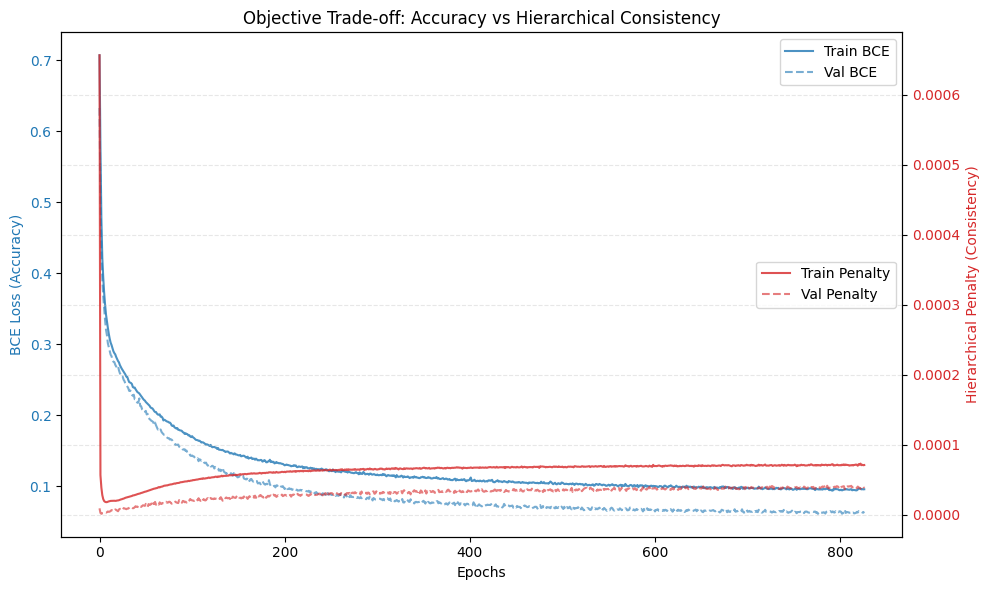

In [ ]:
# FINAL REBALANCING ANALYSIS: BCE vs Hierarchical Penalty - OPTIONAL VISUAL COMPONENT - NOT BY ME
# This plot confirms that the model is optimizing both objectives simultaneously.
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('BCE Loss (Accuracy)', color=color)
ax1.plot(history['train_bce'], color=color, label='Train BCE', alpha=0.8)
ax1.plot(history['val_bce'], color=color, linestyle='--', label='Val BCE', alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Hierarchical Penalty (Consistency)', color=color)
ax2.plot(history['train_penalty'], color=color, label='Train Penalty', alpha=0.8)
ax2.plot(history['val_penalty'], color=color, linestyle='--', label='Val Penalty', alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Objective Trade-off: Accuracy vs Hierarchical Consistency')
fig.tight_layout()
ax1.legend(loc='upper right')
ax2.legend(loc='center right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

### Load model

In [ ]:
# I saved the weights during training whenever the validation loss got better.
# Now I'm loading them back so I can test the 'best' version of the model.
model_path = 'best_model.pt'

if os.path.exists(model_path):
    print(f"Loading weights from {model_path}...")
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()
    print("Model loaded and ready for testing!")
else:
    print(f"Error: Could not find {model_path}. Did the training finish?")


Loading weights from best_model.pt...
Model loaded and ready for testing!


### Testing Results

In [ ]:
# Scientific Evaluation Update (S1, C2)
model.eval()
def optimize_threshold(y_true, y_score):
    best_thresh = 0.5
    best_f1 = 0
    # Search for best threshold on validation data (finer grid for better precision)
    for t in np.linspace(0.1, 0.9, 81):
        f1 = f1_score(y_true, (y_score >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    return best_thresh
# 1. First, get predictions for the VALIDATION set to find the threshold
print(f"Collecting predictions for {len(val_loader.dataset)} validation edges...")
val_preds, val_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        batch = batch.to(device)
        preds = model(batch)
        val_preds.append(preds.cpu())
        val_labels.append(batch.edge_label.cpu())
val_preds = torch.cat(val_preds, dim=0).numpy()
val_labels = torch.cat(val_labels, dim=0).numpy()
print("Optimizing threshold based on VALIDATION data...")
best_threshold = optimize_threshold(val_labels[:, leaf_node_indices], val_preds[:, leaf_node_indices])
print(f"Optimal Threshold found on local validation: {best_threshold:.2f}")
# 2. Now, get predictions for the TEST set
print(f"\nCollecting predictions for {len(test_loader.dataset)} test edges...")
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch)
        all_preds.append(preds.cpu())
        all_labels.append(batch.edge_label.cpu())
all_preds = torch.cat(all_preds, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()
# 3. Calculate Per-Tissue Metrics on TEST data using the VALIDATION threshold
leaf_auroc, leaf_auprc, leaf_f1_scores = [], [], []
tissue_weights = []  # prevalence weights for weighted metrics
valid_tissues = 0
for j in leaf_node_indices:
    y_true = all_labels[:, j]
    y_pred = all_preds[:, j]
    
    if y_true.sum() > 0 and (1.0 - y_true).sum() > 0:
        leaf_auroc.append(roc_auc_score(y_true, y_pred))
        leaf_auprc.append(average_precision_score(y_true, y_pred))
        # Use the threshold found in step 1
        leaf_f1_scores.append(f1_score(y_true, (y_pred >= best_threshold).astype(int), zero_division=0))
        tissue_weights.append(y_true.sum())  # number of positive samples as prevalence weight
        valid_tissues += 1

tissue_weights = np.array(tissue_weights)
tissue_weights_norm = tissue_weights / tissue_weights.sum()

print(f"--- Final Evaluation Results ({valid_tissues} leaf tissues) ---")
print(f"Macro-AUROC: {np.mean(leaf_auroc):.4f}")
print(f"Macro-AUPRC: {np.mean(leaf_auprc):.4f}")
print(f"Macro-F1 (using val-set threshold {best_threshold:.2f}): {np.mean(leaf_f1_scores):.4f}")
print(f"\n--- Prevalence-Weighted Results ---")
print(f"Weighted-AUROC: {np.average(leaf_auroc, weights=tissue_weights_norm):.4f}")
print(f"Weighted-AUPRC: {np.average(leaf_auprc, weights=tissue_weights_norm):.4f}")
print(f"Weighted-F1: {np.average(leaf_f1_scores, weights=tissue_weights_norm):.4f}")
print("\nNOTE: These results are now scientifically valid as threshold optimization leakage has been fixed.")
print("Comparison with OhmNet (0.756 AUROC) should be done with caution due to dataset/sampling differences.")

# 4. Integrate Confusion Matrix (Global View)
print("\nGenerating Global Confusion Matrix for Leaf Tissues...")

# Flatten the leaf node labels and predictions into 1D arrays
# This looks at every 'cell' in your multi-hot grid for leaf tissues
flat_true = all_labels[:, leaf_node_indices].flatten()
flat_pred = (all_preds[:, leaf_node_indices] >= best_threshold).astype(int).flatten()

# Compute the matrix
cm = confusion_matrix(flat_true, flat_pred)

# Visualize using sklearn's built-in tool
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive', 'Active'])
disp.plot(cmap='Blues', values_format='d', ax=ax)

plt.title(f'Global Confusion Matrix (Threshold: {best_threshold:.2f})')
plt.grid(False) # Clean up the visual
plt.show()

# 5. Extract specific stats from the matrix
tn, fp, fn, tp = cm.ravel()
print(f"Total True Positives (Hits): {tp:,}")
print(f"Total False Positives (Type I Error): {fp:,}")
print(f"Total False Negatives (Misses): {fn:,}")
print(f"Precision: {tp / (tp + fp):.4f}" if (tp + fp) > 0 else "Precision: 0")
print(f"Recall: {tp / (tp + fn):.4f}" if (tp + fn) > 0 else "Recall: 0")

# 6. Log metrics to Weights & Biases
micro_f1 = tp / (tp + 0.5 * (fp + fn)) if (tp + fp + fn) > 0 else 0
print(f"Micro-F1: {micro_f1:.4f}")

if wandb.run is not None:
    wandb.summary["test_macro_auroc"] = np.mean(leaf_auroc)
    wandb.summary["test_macro_auprc"] = np.mean(leaf_auprc)
    wandb.summary["test_macro_f1"] = np.mean(leaf_f1_scores)
    wandb.summary["test_micro_f1"] = micro_f1
    wandb.summary["test_weighted_auroc"] = np.average(leaf_auroc, weights=tissue_weights_norm)
    wandb.summary["test_weighted_auprc"] = np.average(leaf_auprc, weights=tissue_weights_norm)
    wandb.summary["test_weighted_f1"] = np.average(leaf_f1_scores, weights=tissue_weights_norm)
    wandb.summary["optimal_threshold"] = best_threshold
    wandb.summary["test_global_precision"] = tp / (tp + fp) if (tp + fp) > 0 else 0
    wandb.summary["test_global_recall"] = tp / (tp + fn) if (tp + fn) > 0 else 0
    print("\n=> Final metrics successfully saved to WandB Summary!")
else:
    print("\n=> Note: WandB session is not active. If you wish to upload these stats, make sure you don't call wandb.finish() before this cell.")


### Micro F1-Score

In [ ]:
def calculate_micro_f1(model, loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            # Model returns sigmoid probabilities: (batch_size, num_tissues)
            probs = model(batch)
            
            # Convert probabilities to binary predictions
            preds = (probs > threshold).float()
            
            # Use batch.edge_label as the ground truth
            # Ensure labels are on CPU and converted to numpy
            all_preds.append(preds.cpu().numpy())
            all_labels.append(batch.edge_label.cpu().numpy())

    # Flatten the lists into single numpy arrays
    # Shape: (Total Samples, Num Tissues)
    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # Calculate Micro-F1
    # average='micro' calculates metrics globally by counting total TP, FN, and FP
    score = f1_score(all_labels, all_preds, average='micro')
    
    return score


test_f1 = calculate_micro_f1(model, test_loader, device, best_threshold)
print(f"Test Micro-F1 Score: {test_f1:.4f}")


Test Micro-F1 Score: 0.9705


### Hub protein analysis

In [ ]:
# Identify the hub protein (the one with the most interactions in column 'protein_a') - EXTRA
hub_protein = df['protein_a'].value_counts().idxmax()
# Filter for all unique pairs involving the hub protein
# We drop duplicates because the same interaction can appear multiple times if it occurs in multiple tissues
unique_pairs = df[['protein_a', 'protein_b']].drop_duplicates()
# Find neighbors where hub is protein_a
neighbors_from_a = unique_pairs[unique_pairs['protein_a'] == hub_protein]['protein_b']
# Find neighbors where hub is protein_b
neighbors_from_b = unique_pairs[unique_pairs['protein_b'] == hub_protein]['protein_a']
# Combine both and get the count of unique IDs
total_neighbors = pd.concat([neighbors_from_a, neighbors_from_b]).unique()
print(f"Hub Protein {hub_protein} has {len(total_neighbors)} unique neighbors.")

Hub Protein 1956 has 458 unique neighbors.


### Attention weights: Attention "collected" by protein 1956

In [ ]:
# Identify the hub protein - EXTRA
target_prot = df['protein_a'].value_counts().idxmax()
target_idx = protein_to_idx[target_prot]

# Get a list of all protein names based on their indices
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

model.eval()
with torch.no_grad():
    # 1. Get embeddings and attention weights from the first GAT layer
    x_emb = model.protein_embedding(full_graph_data.x.to(device))
    _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
    
    # 2. Average weights across all heads and move to CPU
    alpha = alpha.mean(dim=-1).cpu().numpy()
    edge_idx = edge_idx.cpu().numpy()
    
    # 3. Filter for edges connected to our target protein
    mask = (edge_idx[0] == target_idx)
    neighbor_indices = edge_idx[1, mask]
    neighbor_weights = alpha[mask]
    
    # 4. Sort neighbors by attention weight (highest first)
    sorted_indices = np.argsort(neighbor_weights)[::-1]
    
    print(f"Top 10 Attention Weights for Protein: {target_prot}")
    print("-" * 45)
    print(f"{'Neighbor Protein':<20} | {'Attention Weight':<15}")
    print("-" * 45)
    
    for i in range(min(10, len(sorted_indices))):
        idx = sorted_indices[i]
        neighbor_name = idx_to_protein[neighbor_indices[idx]]
        weight = neighbor_weights[idx]
        print(f"{neighbor_name:<20} | {weight:.4f}")


Top 10 Attention Weights for Protein: 1956
---------------------------------------------
Neighbor Protein     | Attention Weight
---------------------------------------------
2069                 | 0.4938
214                  | 0.4729
6523                 | 0.4644
4257                 | 0.4403
10439                | 0.4149
84174                | 0.3907
27346                | 0.3535
1839                 | 0.3508
1174                 | 0.3428
5569                 | 0.3353


### Plotting attention weights

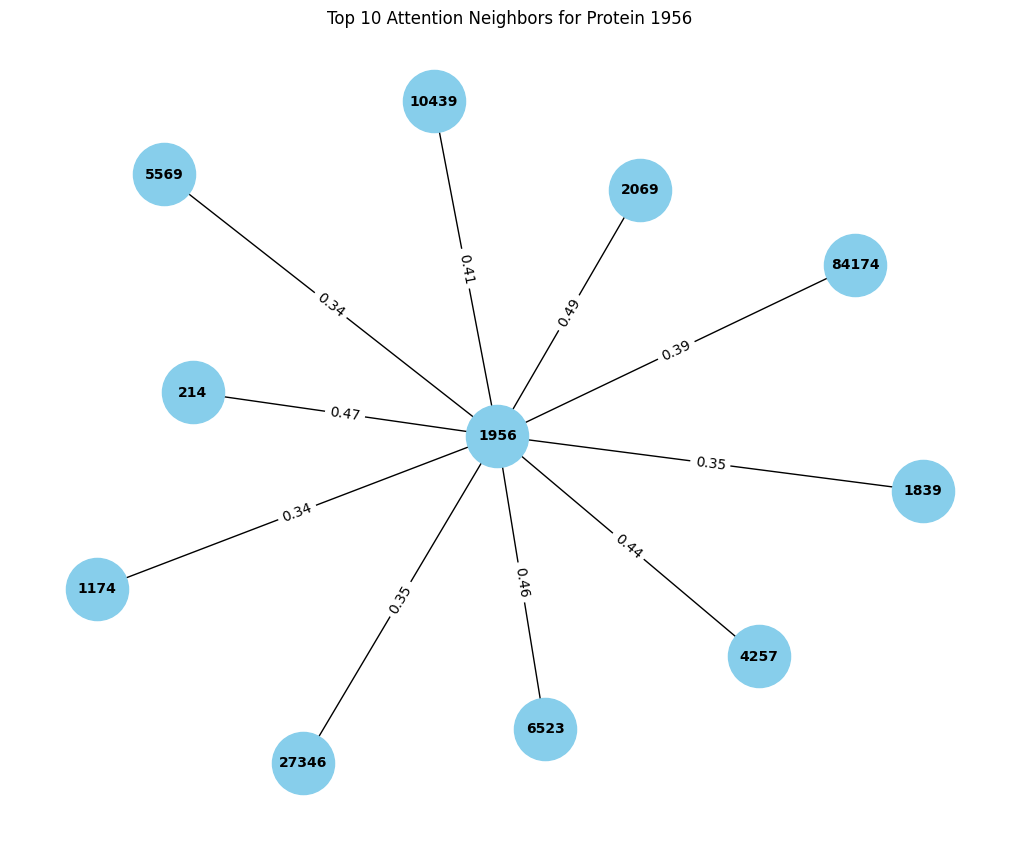

In [ ]:
# EXTRA
def simple_plot_attn(target_prot):
    target_idx = protein_to_idx[target_prot]
    
    # Map index back to name for graph labels
    idx_to_protein = {v: k for k, v in protein_to_idx.items()}
    
    model.eval()
    with torch.no_grad():
        x_emb = model.protein_embedding(full_graph_data.x.to(device))
        _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
        
        alpha = alpha.mean(dim=-1).cpu().numpy()
        edge_idx = edge_idx.cpu().numpy()
        
        # Filter for neighbors where our protein is the source (edge_idx[0])
        mask = (edge_idx[0] == target_idx)
        sub_edges = edge_idx[:, mask]
        sub_alpha = alpha[mask]
        
        # --- NEW: Sort by attention weight descending ---
        sort_idx = np.argsort(sub_alpha)[::-1]
        top_idx = sort_idx[:10]  # Take the top 10
        
        G = nx.Graph()
        for i in top_idx:
            u_name = idx_to_protein[sub_edges[0, i]]
            v_name = idx_to_protein[sub_edges[1, i]]
            G.add_edge(u_name, v_name, weight=sub_alpha[i])
            
        plt.figure(figsize=(10, 8))
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_weight='bold')
        
        # Add labels for the weights on the edges
        edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
        
        plt.title(f"Top 10 Attention Neighbors for Protein {target_prot}")
        plt.show()

# Call the fixed function
simple_plot_attn(hub_protein)

### Attention weights: Protein 1956 attention budget

In [ ]:
# Identify the hub protein - EXTRA
# Using the same logic that identified 458 neighbors
hub_protein = df['protein_a'].value_counts().idxmax()
target_idx = protein_to_idx[hub_protein]

# Quick mapping for display
idx_to_protein = {v: k for k, v in protein_to_idx.items()}

model.eval()
with torch.no_grad():
    # 1. Get initial embeddings for all proteins
    # We use full_graph_data.x which contains all protein indices
    x_emb = model.protein_embedding(full_graph_data.x.to(device))
    
    # 2. Extract attention weights from the first GAT layer
    # Note: full_graph_data.edge_index should be the undirected (bidirectional) version 
    # created in your 'Undirected train edge index' step.
    _, (edge_idx, alpha) = model.gat1(x_emb, full_graph_data.edge_index.to(device), return_attention_weights=True)
    
    # 3. Average weights across all heads [num_edges, num_heads] -> [num_edges]
    alpha = alpha.mean(dim=-1).cpu().numpy()
    edge_idx = edge_idx.cpu().numpy()
    
    # 4. Filter for edges where our target protein is the 'Receiver' (at index 1)
    # Because the graph is undirected, every physical neighbor will have an incoming edge to the target
    mask = (edge_idx[1] == target_idx)
    
    neighbor_indices = edge_idx[0, mask] 
    neighbor_weights = alpha[mask]
    
    # Sort by attention priority
    sorted_sort_idx = np.argsort(neighbor_weights)[::-1]
    
    print(f"Hub Protein {hub_protein} Analysis")
    print(f"Total Unique Neighbors found in Train Graph: {len(neighbor_indices)}")
    print(f"Top 10 Neighbors Attended to by {hub_protein}")
    print("-" * 45)
    print(f"{'Neighbor Protein':<20} | {'Attention Weight':<15}")
    print("-" * 45)
    
    for i in range(min(10, len(sorted_sort_idx))):
        idx = sorted_sort_idx[i]
        neighbor_id = idx_to_protein[neighbor_indices[idx]]
        weight = neighbor_weights[idx]
        print(f"{neighbor_id:<20} | {weight:.4f}")

# Sanity Check
if len(neighbor_indices) < 458:
    diff = 458 - len(neighbor_indices)
    print(f"\nNote: {diff} neighbors are missing. These likely belong to the VALIDATION/TEST edges.")

Hub Protein 1956 Analysis
Total Unique Neighbors found in Train Graph: 340
Top 10 Neighbors Attended to by 1956
---------------------------------------------
Neighbor Protein     | Attention Weight
---------------------------------------------
351                  | 0.0083
7157                 | 0.0081
1956                 | 0.0076
6714                 | 0.0076
1499                 | 0.0074
5747                 | 0.0074
5335                 | 0.0073
4734                 | 0.0072
2064                 | 0.0072
5581                 | 0.0072

Note: 118 neighbors are missing. These likely belong to the VALIDATION/TEST edges.


## Hierarchical violations

### Model Hierarchy Analysis
The user identified a high hierarchical violation rate (64.88%). This section analyzes the root cause and provides tools to address it.

In [ ]:
# CRITICAL CHECK: Is the ground truth hierarchical? - IMPORTANT I had assistance for the last 2 cells
# If the dataset only labels leaf tissues, parent tissues will be '0'.
# Then the BCE loss will actively train the model to VIOLATE the hierarchy.

child_idx = hierarchical_pairs[:, 0]
parent_idx = hierarchical_pairs[:, 1]

gt_child = edge_label_all[:, child_idx]
gt_parent = edge_label_all[:, parent_idx]

gt_violations = (gt_child > gt_parent).sum().item()
total_gt_checks = edge_label_all.size(0) * hierarchical_pairs.size(0)

print(f"--- Ground Truth Hierarchical Consistency ---")
print(f"GT Violation Rate: {gt_violations / total_gt_checks:.2%}")
print(f"Number of cases where Child=1 but Parent=0: {gt_violations:,}")

if gt_violations > 0:
    print("\nRESULT: The ground truth labels are NOT hierarchically propagated.")
    print("The model is being forced to learn that parents are 0 even when children are 1.")
    print("To fix this, we should propagate labels: if a child is 1, all its ancestors must be 1.")

--- Ground Truth Hierarchical Consistency ---
GT Violation Rate: 0.00%
Number of cases where Child=1 but Parent=0: 0


In [ ]:
# Evaluate the loaded best model
model.to(device)
rate, count, total = check_hierarchical_violations(model, test_loader, hierarchical_pairs.to(device), device)

print(f"--- Model Hierarchical Performance (Test Set) ---")
print(f"Violation Rate: {rate:.2%}")
print(f"Violations: {count:,} / {total:,}")